In [ ]:
import time
from dataclasses import replace
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import random
import sys

ROOT = Path.cwd()
if not (ROOT / "generation").exists() and (ROOT.parent / "generation").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import torch
from simulation.arraySim import arrayResponseBatch
from scripts.arrayBatch import ArrayBatch
from scripts.arraySpec import ArraySpec
from scripts.batchFactory import generateBatch
from scripts.coordinateTransforms import mapLLAtoArrayAZEL
from scripts.targetSpec import TargetBatch, TargetLike
from ui.export_target import load_target_from_pt


def _defaultDevice() -> torch.device:
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


def _synchronize(device: torch.device) -> None:
    if device.type == "cuda":
        torch.cuda.synchronize(device)
    elif device.type == "mps" and hasattr(torch.mps, "synchronize"):
        torch.mps.synchronize()


def _saveResults(results: dict[str, Any], savefile: str | Path | None) -> None:
    if savefile is None:
        return

    savePath = Path(savefile)
    if savePath.parent != Path("."):
        savePath.parent.mkdir(parents=True, exist_ok=True)
    torch.save(results, savePath)


def _shapeNumel(shape: tuple[int, ...]) -> int:
    count = 1
    for dim in shape:
        count *= int(dim)
    return count


def _benchmarkArrayResponse(
    batch: ArrayBatch,
    target: TargetLike,
    samples: int,
    chunkSize: int | None = None,
) -> dict[str, Any]:
    if samples <= 0:
        raise ValueError("samples must be a positive integer")
    if chunkSize is not None and chunkSize <= 0:
        raise ValueError("chunkSize must be positive when provided")
    if isinstance(target, TargetBatch) and target.batchSize != batch.batchSize:
        raise ValueError("TargetBatch batch size must match ArrayBatch batch size")

    target = target.to(batch.device, batch.dtype)
    targetArea = torch.stack([target.searchLatitudes, target.searchLongitudes], dim=-1)

    with torch.inference_mode():
        warmupAZEL = mapLLAtoArrayAZEL(batch, targetArea)
        _ = arrayResponseBatch(
            batch,
            warmupAZEL,
            chunkSize=chunkSize,
            dB=False,
            normalize=False,
        )
        _synchronize(batch.device)

        timingsMS: list[float] = []
        lastResponseShape: tuple[int, ...] | None = None
        for _ in range(samples):
            _synchronize(batch.device)
            startTime = time.perf_counter()

            relativeTargetAZEL = mapLLAtoArrayAZEL(batch, targetArea)
            response = arrayResponseBatch(
                batch,
                relativeTargetAZEL,
                chunkSize=chunkSize,
                dB=False,
                normalize=False,
            )

            _synchronize(batch.device)
            timingsMS.append((time.perf_counter() - startTime) * 1000.0)
            lastResponseShape = tuple(response.shape)

    timingTensor = torch.tensor(timingsMS, dtype=torch.float64)
    targetShape = tuple(int(dim) for dim in target.targetShape)
    return {
        "samples": samples,
        "batch_size": batch.batchSize,
        "element_count": batch.N,
        "target_shape": targetShape,
        "target_pixels": _shapeNumel(targetShape),
        "response_shape": lastResponseShape,
        "device": str(batch.device),
        "dtype": str(batch.dtype),
        "chunk_size": chunkSize,
        "metrics_ms": {
            "mean": float(timingTensor.mean().item()),
            "std": float(timingTensor.std(unbiased=False).item()),
            "min": float(timingTensor.min().item()),
            "max": float(timingTensor.max().item()),
            "median": float(timingTensor.median().item()),
            "total": float(timingTensor.sum().item()),
        },
        "timings_ms": timingsMS,
    }


def simBatch(
    batch: ArrayBatch,
    target: TargetLike,
    samples: int,
    savefile: str | Path | None = None,
    chunkSize: int | None = None,
) -> dict[str, Any]:
    results = _benchmarkArrayResponse(
        batch=batch,
        target=target,
        samples=samples,
        chunkSize=chunkSize,
    )
    _saveResults(results, savefile)
    return results


def simSweep(
    baseSpec: ArraySpec,
    baseTarget: TargetLike,
    chunkSizes: list[int | None],
    allowedElementCounts: list[int],
    targetDecimations: list[int],
    experimentName: str,
    samples: int,
    batchSize: int | None = None,
    weightsType: str = "uniform",
    savefile: str | Path | None = None,
    device: torch.device | None = None,
    dtype: torch.dtype | None = torch.float32,
    verbose: bool = True,
) -> dict[str, Any]:
    if not chunkSizes:
        raise ValueError("chunkSizes must contain at least one value")
    if not allowedElementCounts:
        raise ValueError("allowedElementCounts must contain at least one value")
    if not targetDecimations:
        raise ValueError("targetDecimations must contain at least one value")

    if batchSize is None:
        batchSize = baseTarget.batchSize if isinstance(baseTarget, TargetBatch) else 1
    if isinstance(baseTarget, TargetBatch) and batchSize != baseTarget.batchSize:
        raise ValueError("batchSize must match TargetBatch.batchSize for batched targets")

    if device is None:
        device = _defaultDevice()

    records: list[dict[str, Any]] = []
    experimentCount = len(chunkSizes) * len(allowedElementCounts) * len(targetDecimations)
    experimentIndex = 0

    for chunkSize in chunkSizes:
        for requestedElementCount in allowedElementCounts:
            for targetDecimation in targetDecimations:
                experimentIndex += 1
                if targetDecimation <= 0:
                    raise ValueError("targetDecimations must contain only positive integers")

                if verbose:
                    print(
                        f"[{experimentIndex}/{experimentCount}] "
                        f"chunkSize={chunkSize} "
                        f"allowedElementCount={requestedElementCount} "
                        f"targetDecimation={targetDecimation}"
                    )

                sweepSpec = replace(baseSpec, allowedElementCount=(int(requestedElementCount),))
                sweepTarget = baseTarget.decimate(int(targetDecimation))
                sweepBatch = generateBatch(
                    sweepSpec,
                    batchSize=batchSize,
                    device=device,
                    dtype=dtype,
                    elementCount=int(requestedElementCount),
                    weightsType=weightsType,
                )

                benchmark = simBatch(
                    batch=sweepBatch,
                    target=sweepTarget,
                    samples=samples,
                    savefile=None,
                    chunkSize=chunkSize,
                )

                record = {
                    "experiment_name": experimentName,
                    "chunk_size": chunkSize,
                    "requested_element_count": int(requestedElementCount),
                    "actual_element_count": int(sweepBatch.N),
                    "target_decimation": int(targetDecimation),
                    "target_shape": benchmark["target_shape"],
                    "target_pixels": benchmark["target_pixels"],
                    "mean_ms": benchmark["metrics_ms"]["mean"],
                    "std_ms": benchmark["metrics_ms"]["std"],
                    "min_ms": benchmark["metrics_ms"]["min"],
                    "max_ms": benchmark["metrics_ms"]["max"],
                    "median_ms": benchmark["metrics_ms"]["median"],
                    "total_ms": benchmark["metrics_ms"]["total"],
                    "benchmark": benchmark,
                }
                records.append(record)

    results = {
        "experiment_name": experimentName,
        "samples": samples,
        "batch_size": batchSize,
        "weights_type": weightsType,
        "device": str(device),
        "dtype": str(dtype),
        "sweep_parameters": {
            "chunk_sizes": chunkSizes,
            "allowed_element_counts": [int(value) for value in allowedElementCounts],
            "target_decimations": [int(value) for value in targetDecimations],
        },
        "records": records,
    }
    _saveResults(results, savefile)
    return results


def _loadSweepResults(sweepResults: dict[str, Any] | str | Path) -> dict[str, Any]:
    if isinstance(sweepResults, (str, Path)):
        return torch.load(sweepResults, weights_only=False)
    return sweepResults


def _formatLargeNumber(value: int | float) -> str:
    numericValue = float(value)
    absoluteValue = abs(numericValue)

    if absoluteValue >= 1_000_000_000:
        scaledValue = numericValue / 1_000_000_000
        suffix = "B"
    elif absoluteValue >= 1_000_000:
        scaledValue = numericValue / 1_000_000
        suffix = "M"
    elif absoluteValue >= 1_000:
        scaledValue = numericValue / 1_000
        suffix = "k"
    else:
        return str(int(numericValue)) if numericValue.is_integer() else f"{numericValue:g}"

    if abs(scaledValue - round(scaledValue)) < 1e-9:
        return f"{int(round(scaledValue))}{suffix}"
    return f"{scaledValue:.1f}{suffix}"


def _formatSweepValue(
    field: str,
    value: Any,
    record: dict[str, Any] | None = None,
) -> str:
    if field == "chunk_size":
        return "auto" if value is None else _formatLargeNumber(value)
    if field == "requested_element_count":
        return _formatLargeNumber(value)
    if field == "target_decimation":
        if record is None or "target_pixels" not in record:
            return str(value)
        return f"{value}\\n({record['target_pixels']} px)"
    return str(value)


def _sortKey(value: Any) -> tuple[int, float | str]:
    if value is None:
        return (2, float("inf"))
    if isinstance(value, (int, float)):
        return (0, float(value))
    return (1, str(value))


def _seriesLabel(seriesFields: list[str], seriesKey: tuple[Any, ...]) -> str:
    if not seriesFields:
        return "all settings"

    parts: list[str] = []
    for field, value in zip(seriesFields, seriesKey):
        if field == "requested_element_count":
            parts.append(f"elements={_formatSweepValue(field, value)}")
        elif field == "chunk_size":
            parts.append(f"chunk={_formatSweepValue(field, value)}")
        elif field == "target_decimation":
            parts.append(f"decim={value}")
        else:
            parts.append(f"{field}={value}")
    return ", ".join(parts)


def _groupSeries(
    records: list[dict[str, Any]],
    field: str,
    seriesFields: list[str],
    metric: str,
) -> dict[tuple[Any, ...], dict[Any, list[float]]]:
    grouped: dict[tuple[Any, ...], dict[Any, list[float]]] = {}
    for record in records:
        seriesKey = tuple(record[name] for name in seriesFields)
        xKey = record[field]
        grouped.setdefault(seriesKey, {}).setdefault(xKey, []).append(float(record[metric]))
    return grouped


def plotSweepResults(
    sweepResults: dict[str, Any] | str | Path,
    metric: str = "mean_ms",
    aggregate: str = "mean",
    baselineSavefile: str | Path | None = None,
) -> tuple:
    sweepResults = _loadSweepResults(sweepResults)
    baselineResults = None
    if baselineSavefile is not None:
        baselineResults = _loadSweepResults(baselineSavefile)

    records = sweepResults.get("records", [])
    if not records:
        raise ValueError("sweepResults does not contain any records")
    if metric not in records[0]:
        raise ValueError(f"metric '{metric}' is not present in sweep records")
    if aggregate not in {"mean", "min", "max"}:
        raise ValueError("aggregate must be one of: 'mean', 'min', 'max'")

    baselineRecords: list[dict[str, Any]] = []
    baselineLabel: str | None = None
    if baselineResults is not None:
        baselineRecords = baselineResults.get("records", [])
        if not baselineRecords:
            raise ValueError("baselineSavefile does not contain any sweep records")
        if metric not in baselineRecords[0]:
            raise ValueError(f"metric '{metric}' is not present in baseline sweep records")
        baselineLabel = baselineResults.get("experiment_name", Path(baselineSavefile).stem)

    allRecords = records + baselineRecords
    plotSpecs = [
        {"field": "chunk_size", "title": "Chunk Size", "use_log_scale": True},
        {"field": "requested_element_count", "title": "Allowed Element Count", "use_log_scale": False},
        {"field": "target_decimation", "title": "Target Decimation", "use_log_scale": False},
    ]
    varyingFields = [
        spec["field"]
        for spec in plotSpecs
        if len({record[spec['field']] for record in allRecords}) > 1
    ]

    def reduceValues(values: list[float]) -> float:
        if aggregate == "mean":
            return sum(values) / len(values)
        if aggregate == "min":
            return min(values)
        return max(values)

    figure, axes = plt.subplots(1, 3, figsize=(18, 4.5), constrained_layout=True)
    currentLabel = sweepResults.get("experiment_name", "Current Sweep")
    colorCycle = plt.rcParams["axes.prop_cycle"].by_key().get("color", [f"C{i}" for i in range(10)])

    for axis, spec in zip(axes, plotSpecs):
        field = spec["field"]
        title = spec["title"]
        seriesFields = [name for name in varyingFields if name != field]
        if field != "chunk_size" and len(seriesFields) > 1:
            seriesFields = []
        currentSeries = _groupSeries(records, field=field, seriesFields=seriesFields, metric=metric)
        baselineSeries = _groupSeries(
            baselineRecords,
            field=field,
            seriesFields=seriesFields,
            metric=metric,
        )

        labelRecords: dict[Any, dict[str, Any]] = {}
        for record in allRecords:
            labelRecords.setdefault(record[field], record)

        allSeriesKeys = sorted(
            set(currentSeries) | set(baselineSeries),
            key=lambda key: tuple(_sortKey(value) for value in key),
        )
        allXKeys = sorted(
            {
                xKey
                for series in [*currentSeries.values(), *baselineSeries.values()]
                for xKey in series
            },
            key=_sortKey,
        )

        if spec["use_log_scale"]:
            numericXKeys = [key for key in allXKeys if key is not None]
            xMap = {key: float(key) for key in numericXKeys}
            xticks = [float(key) for key in numericXKeys]
            xticklabels = [
                _formatSweepValue(field, key, labelRecords.get(key)) for key in numericXKeys
            ]

            if None in allXKeys:
                autoPosition = (float(numericXKeys[-1]) * 2.0) if numericXKeys else 1.0
                xMap[None] = autoPosition
                xticks.append(autoPosition)
                xticklabels.append(_formatSweepValue(field, None))

            axis.set_xscale("log")
        else:
            xMap = {key: index for index, key in enumerate(allXKeys)}
            xticks = list(xMap.values())
            xticklabels = [
                _formatSweepValue(field, key, labelRecords.get(key)) for key in allXKeys
            ]

        for seriesIndex, seriesKey in enumerate(allSeriesKeys):
            color = colorCycle[seriesIndex % len(colorCycle)]
            currentValues = currentSeries.get(seriesKey, {})
            baselineValues = baselineSeries.get(seriesKey, {})
            seriesLabel = _seriesLabel(seriesFields, seriesKey)

            if currentValues:
                xValues = [xMap[key] for key in allXKeys if key in currentValues]
                yValues = [reduceValues(currentValues[key]) for key in allXKeys if key in currentValues]
                currentSeriesLabel = currentLabel if not seriesFields else f"{currentLabel}: {seriesLabel}"
                axis.plot(
                    xValues,
                    yValues,
                    marker="o",
                    linewidth=2,
                    color=color,
                    label=currentSeriesLabel,
                )

            if baselineValues:
                baselineXValues = [xMap[key] for key in allXKeys if key in baselineValues]
                baselineYValues = [
                    reduceValues(baselineValues[key]) for key in allXKeys if key in baselineValues
                ]
                comparisonLabel = baselineLabel if not seriesFields else f"{baselineLabel}: {seriesLabel}"
                axis.plot(
                    baselineXValues,
                    baselineYValues,
                    marker="s",
                    linestyle="--",
                    linewidth=2,
                    color=color,
                    alpha=0.85,
                    label=comparisonLabel,
                )

        axis.set_xticks(xticks)
        axis.set_xticklabels(xticklabels, rotation=25)
        axis.set_title(title)
        axis.set_xlabel(title)
        axis.set_ylabel(metric.replace("_", " "))
        axis.grid(True, alpha=0.3)

        if len(allSeriesKeys) > 1 or baselineRecords:
            legendTitle = None
            if seriesFields:
                legendTitle = ", ".join(name.replace("_", " ") for name in seriesFields)
            axis.legend(title=legendTitle, fontsize="small")

    title = f"{currentLabel} ({aggregate} {metric})"
    if baselineLabel is not None:
        title = f"{title} vs {baselineLabel}"
    figure.suptitle(title)
    plt.show()
    return figure, list(axes)


# Example single benchmark:
# device = _defaultDevice()
# dtype = torch.float32
# target = load_target_from_pt(ROOT / "target_spec.pt")
# spec = ArraySpec(
#     geometry="UCA",
#     allowedAspectRatio=[1],
#     allowedElementCount=[1_000],
#     latitudeRange=(15, 15),
#     altitudeRange=(7e6, 7e6),
# )
# batch = generateBatch(spec, batchSize=1, device=device, dtype=dtype, weightsType="uniform")
# simBatch(batch, target.decimate(4), samples=10, savefile=None)

# Example sweep:
# sweep = simSweep(
#     baseSpec=spec,
#     baseTarget=target,
#     chunkSizes=[None, 250_000, 1_000_000],
#     allowedElementCounts=[256, 512, 1_000],
#     targetDecimations=[2, 4, 8],
#     experimentName="uca_speed_sweep",
#     samples=5,
#     batchSize=1,
#     weightsType="uniform",
#     savefile="benchmarks/uca_speed_sweep.pt",
# )
# plotSweepResults(sweep)


[1/18] chunkSize=500000 allowedElementCount=10000 targetDecimation=6
[2/18] chunkSize=500000 allowedElementCount=50000 targetDecimation=6
[3/18] chunkSize=500000 allowedElementCount=100000 targetDecimation=6
[4/18] chunkSize=1000000 allowedElementCount=10000 targetDecimation=6
[5/18] chunkSize=1000000 allowedElementCount=50000 targetDecimation=6
[6/18] chunkSize=1000000 allowedElementCount=100000 targetDecimation=6
[7/18] chunkSize=10000000 allowedElementCount=10000 targetDecimation=6
[8/18] chunkSize=10000000 allowedElementCount=50000 targetDecimation=6
[9/18] chunkSize=10000000 allowedElementCount=100000 targetDecimation=6
[10/18] chunkSize=100000000 allowedElementCount=10000 targetDecimation=6
[11/18] chunkSize=100000000 allowedElementCount=50000 targetDecimation=6
[12/18] chunkSize=100000000 allowedElementCount=100000 targetDecimation=6
[13/18] chunkSize=1000000000 allowedElementCount=10000 targetDecimation=6
[14/18] chunkSize=1000000000 allowedElementCount=50000 targetDecimation=6

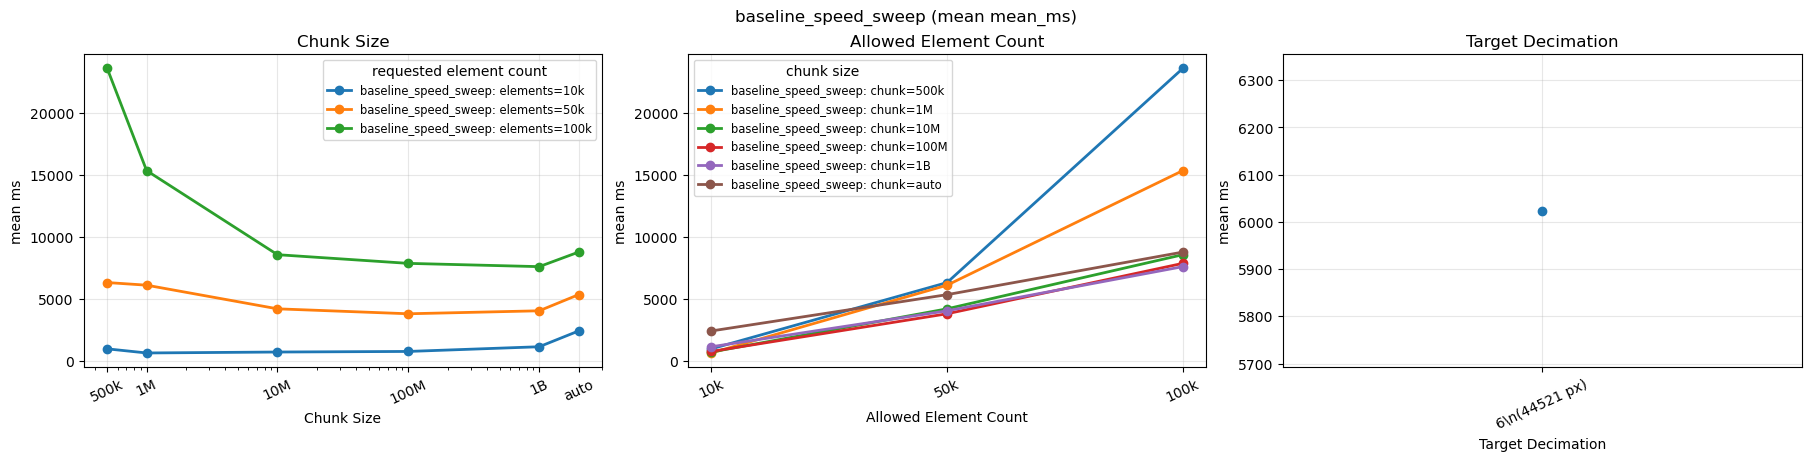

(<Figure size 1800x450 with 3 Axes>,
 [<Axes: title={'center': 'Chunk Size'}, xlabel='Chunk Size', ylabel='mean ms'>,
  <Axes: title={'center': 'Allowed Element Count'}, xlabel='Allowed Element Count', ylabel='mean ms'>,
  <Axes: title={'center': 'Target Decimation'}, xlabel='Target Decimation', ylabel='mean ms'>])

In [4]:
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# Setup device and precision
dtype = torch.float32
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")


# spec = ArraySpec(failRate=0.05, positionJitterSTD=0.01, phaseJitterSTD=0.1)
spec = ArraySpec(geometry="URA", allowedAspectRatio=[1], allowedElementCount=[1_000_000], latitudeRange=(15,15), altitudeRange=(7e6, 7e6))
random = generateBatch(spec, batchSize=50, device=device, dtype=dtype, weightsType="random")
target = load_target_from_pt("../target_spec.pt")
batch = generateBatch(spec, batchSize=1, device=device, dtype=dtype, weightsType="uniform")
#simBatch(batch, target.decimate(4), samples=10, savefile=None)

#Example sweep:
sweep = simSweep(
    baseSpec=spec,
    baseTarget=target,
    chunkSizes=[500_000, 1_000_000, 10_000_000, 100_000_000, 1_000_000_000, None],
    allowedElementCounts=[10_000, 50_000, 100_000],
    targetDecimations=[6],
    experimentName="baseline_speed_sweep",
    samples=5,
    batchSize=10,
    weightsType="random",
    savefile="benchmarks/baseline_speed_sweep.pt",
)
plotSweepResults(sweep)

In [5]:
plotSweepResults(sweep, baselineSavefile="benchmarks/baseline_speed_auto.pt")


FileNotFoundError: [Errno 2] No such file or directory: 'benchmarks/baseline_speed_auto.pt'